# 04 — Indian NBFC Benchmark: Putting Our Model in Real-World Context

## Purpose of this notebook

Notebooks 01-03 built a full PD → LGD/EAD → ECL pipeline on the **South
German Credit dataset** — a well-documented, methodologically convenient
research dataset, chosen so the mechanics (data cleaning, modeling,
IFRS 9 staging, stress testing) could be demonstrated cleanly and
reproducibly.

But this project exists for a specific purpose: a job application to an
**Indian NBFC (Non-Banking Financial Company), Godrej Capital**. Godrej
Capital doesn't lend in 1990s Germany — it lends in India, today, in
housing finance and other retail/SME credit. So before this project is
useful as a demonstration of relevant skill, it needs to be honest about
one thing: **our German dataset's default rate (30%) and our model's
resulting ECL rate (31.4%) are nowhere close to what a real, healthy
Indian lender's numbers look like** — and that gap needs explaining, not
hiding.

This notebook does three things:

1. **Compares** our project's output numbers against real, sourced Indian
   NBFC industry benchmarks and Godrej Capital Group's own disclosed risk
   profile.
2. **Explains why the gap is so large** — it's a feature of the research
   dataset's design, not a flaw in the modeling approach.
3. **Connects the modeling approach to Godrej Capital specifically** —
   arguing why a scenario-based ECL framework (like the one built here)
   is a genuinely useful tool for a young, growing lender, independent of
   the specific numbers underlying it.

**Every number in this notebook is sourced inline.** Nothing here is
invented or estimated by us — where official sources report a range
rather than one precise figure, we present it as a range.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

## Comparison table

All figures below are as-reported in the cited sources. Where a source
reports a range or two time points, we show both rather than collapsing
to a single invented midpoint.

In [2]:
comparison = pd.DataFrame([
    {
        "group": "This project",
        "metric": "South German Credit dataset — observed default rate",
        "value": "30.0%",
        "source": "UCI Machine Learning Repository / Grömping (2019) dataset documentation — "
                   "bad credits are deliberately heavily oversampled for research purposes, "
                   "NOT representative of any real bank's portfolio",
    },
    {
        "group": "This project",
        "metric": "Our PD model — base-case ECL rate",
        "value": "31.4% of portfolio EAD",
        "source": "This project, notebook 03_ecl_calculation.ipynb",
    },
    {
        "group": "Indian NBFC sector",
        "metric": "NBFC sector-wide GNPA (Mar 2025)",
        "value": "~2.9%\u20134.2% (range across RBI publications/periods)",
        "source": "RBI, \u201cTrend and Progress of Banking in India\u201d report, 2025; "
                   "RBI Financial Stability Report (figures vary 2.9%-4.2% by publication/methodology)",
    },
    {
        "group": "Indian NBFC sector",
        "metric": "NBFC-MFI (microfinance) subsegment GNPA (Mar 2025)",
        "value": "~4.1%",
        "source": "RBI, \u201cTrend and Progress of Banking in India\u201d report, 2025",
    },
    {
        "group": "Peer HFCs",
        "metric": "Bajaj Housing Finance \u2014 GNPA (Dec 2025)",
        "value": "0.27%",
        "source": "Bajaj Housing Finance company disclosures",
    },
    {
        "group": "Peer HFCs",
        "metric": "Bajaj Housing Finance \u2014 NNPA (Dec 2025)",
        "value": "0.11%",
        "source": "Bajaj Housing Finance company disclosures",
    },
    {
        "group": "Peer HFCs",
        "metric": "PNB Housing Finance \u2014 GNPA, FY22 vs. current",
        "value": "8.1% (FY22) improved to ~1.5% (current)",
        "source": "PNB Housing Finance company disclosures",
    },
    {
        "group": "Godrej Capital Group",
        "metric": "Credit rating",
        "value": "CRISIL AA+/Stable, ICRA AA+/Stable (2025)",
        "source": "CRISIL and ICRA rating rationale reports, 2025",
    },
    {
        "group": "Godrej Capital Group",
        "metric": "Numeric GNPA / NPA",
        "value": "Not publicly disclosed in rating rationale reports",
        "source": "CRISIL and ICRA rating rationale reports, 2025",
    },
    {
        "group": "Godrej Capital Group",
        "metric": "Book seasoning",
        "value": "GHFL commenced lending Nov 2020; GFL commenced Mar 2022 \u2014 young, unseasoned book",
        "source": "CRISIL and ICRA rating rationale reports, 2025",
    },
])

comparison

,group,metric,value,source
0,This project,South German Credit dataset — observed default...,30.0%,UCI Machine Learning Repository / Grömping (20...
1,This project,Our PD model — base-case ECL rate,31.4% of portfolio EAD,"This project, notebook 03_ecl_calculation.ipynb"
2,Indian NBFC sector,NBFC sector-wide GNPA (Mar 2025),~2.9%–4.2% (range across RBI publications/peri...,"RBI, “Trend and Progress of Banking in India” ..."
3,Indian NBFC sector,NBFC-MFI (microfinance) subsegment GNPA (Mar 2...,~4.1%,"RBI, “Trend and Progress of Banking in India” ..."
4,Peer HFCs,Bajaj Housing Finance — GNPA (Dec 2025),0.27%,Bajaj Housing Finance company disclosures
5,Peer HFCs,Bajaj Housing Finance — NNPA (Dec 2025),0.11%,Bajaj Housing Finance company disclosures
6,Peer HFCs,"PNB Housing Finance — GNPA, FY22 vs. current",8.1% (FY22) improved to ~1.5% (current),PNB Housing Finance company disclosures
7,Godrej Capital Group,Credit rating,"CRISIL AA+/Stable, ICRA AA+/Stable (2025)","CRISIL and ICRA rating rationale reports, 2025"
8,Godrej Capital Group,Numeric GNPA / NPA,Not publicly disclosed in rating rationale rep...,"CRISIL and ICRA rating rationale reports, 2025"
9,Godrej Capital Group,Book seasoning,GHFL commenced lending Nov 2020; GFL commenced...,"CRISIL and ICRA rating rationale reports, 2025"


## Visualizing the scale gap

**Read this chart carefully: it is not an apples-to-apples comparison.**
The South German Credit figures come from a 1990s-era German research
dataset with defaults deliberately oversampled for modeling purposes; the
Indian NBFC figures are real, current, audited industry numbers from a
completely different country, era, and underwriting environment. This
chart exists purely to show **scale and context** — how far apart these
numbers sit — not to claim our model's output "equals" or "predicts" any
real Indian lender's risk. Godrej Capital Group isn't plotted here at all,
since it has no disclosed numeric GNPA to plot (see the table above) —
only its qualitative profile (rating, seasoning) is known.

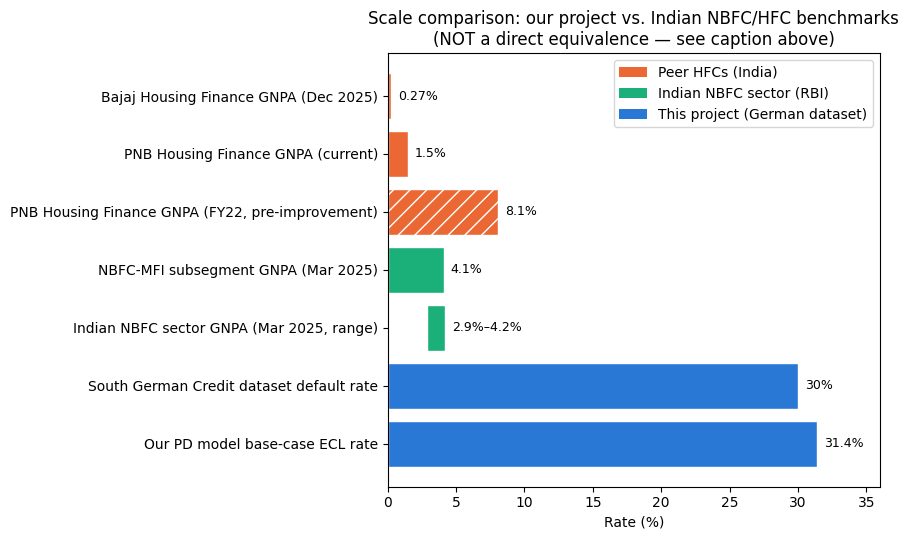

In [3]:
# Categorical colors, one hue per group, used consistently (not cycled).
COLOR_OUR_PROJECT = "#2a78d6"   # blue
COLOR_INDIAN_NBFC = "#1baf7a"   # aqua
COLOR_PEER_HFC = "#eb6834"      # orange

# Each entry is (label, low, high, color, hatch). A single-point value has low == high.
bars = [
    ("Bajaj Housing Finance GNPA (Dec 2025)", 0.27, 0.27, COLOR_PEER_HFC, None),
    ("PNB Housing Finance GNPA (current)", 1.5, 1.5, COLOR_PEER_HFC, None),
    ("PNB Housing Finance GNPA (FY22, pre-improvement)", 8.1, 8.1, COLOR_PEER_HFC, "//"),
    ("NBFC-MFI subsegment GNPA (Mar 2025)", 4.1, 4.1, COLOR_INDIAN_NBFC, None),
    ("Indian NBFC sector GNPA (Mar 2025, range)", 2.9, 4.2, COLOR_INDIAN_NBFC, None),
    ("South German Credit dataset default rate", 30.0, 30.0, COLOR_OUR_PROJECT, None),
    ("Our PD model base-case ECL rate", 31.4, 31.4, COLOR_OUR_PROJECT, None),
]

fig, ax = plt.subplots(figsize=(9, 5.5))

labels = [b[0] for b in bars]
y_pos = range(len(bars))

for y, (label, low, high, color, hatch) in zip(y_pos, bars):
    width = high - low
    if width == 0:
        # Single-point value: draw a normal bar from 0.
        ax.barh(y, low, color=color, hatch=hatch, edgecolor="white")
        ax.text(low + 0.5, y, f"{low:g}%", va="center", fontsize=9)
    else:
        # Range value: draw a floating bar from low to high.
        ax.barh(y, width, left=low, color=color, edgecolor="white")
        ax.text(high + 0.5, y, f"{low:g}%\u2013{high:g}%", va="center", fontsize=9)

ax.set_yticks(list(y_pos))
ax.set_yticklabels(labels)
ax.invert_yaxis()
ax.set_xlim(0, 36)
ax.set_xlabel("Rate (%)")
ax.set_title("Scale comparison: our project vs. Indian NBFC/HFC benchmarks\n(NOT a direct equivalence \u2014 see caption above)")

# Legend by group (fixed color per category, not cycled).
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=COLOR_PEER_HFC, label="Peer HFCs (India)"),
    Patch(facecolor=COLOR_INDIAN_NBFC, label="Indian NBFC sector (RBI)"),
    Patch(facecolor=COLOR_OUR_PROJECT, label="This project (German dataset)"),
]
ax.legend(handles=legend_elements, loc="upper right")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "india_benchmark_comparison.png", dpi=150)
plt.show()

## Why the gap is so large

The chart above shows roughly a **7x-100x gap** between our project's
figures (30%/31.4%) and real Indian lending benchmarks (sub-1% to ~4%).
Two separate reasons explain this — one about the dataset, one about the
underwriting environment:

**1. The German dataset's default rate is a research-sampling artifact,
not a real-world observation.** Per the UCI Machine Learning Repository's
own documentation for this dataset, "bad" credits were deliberately
oversampled relative to their true incidence, specifically so a
classification algorithm would have enough minority-class examples to
learn from. A 30% default rate reflects a **stratified sample built for
modeling convenience**, not the actual default rate of any real bank's
book at the time. Notebook 01 flagged this same point when discussing
class imbalance.

**2. Real Indian retail and housing loan books benefit from underwriting
infrastructure this dataset simply doesn't have.** Modern Indian lenders
screen applicants against **credit bureau records** (CIBIL and others),
typically require **collateral** for housing/secured lending, and apply
**mature, iteratively-refined underwriting standards** built up over
decades of lending experience and regulatory oversight. Under those
conditions, sub-1% to low-single-digit GNPA (as seen in the Bajaj Housing
Finance and PNB Housing Finance figures above) is a **normal outcome for
a well-run book** — not an aspirational best case. The 30%/31.4% figures
in this project are, by design, closer to "how would a model perform on
an adversarially hard dataset with no collateral or bureau data" than to
"what should we expect from a real loan book."

## What this means for Godrej Capital specifically

Godrej Capital Group is rated **CRISIL AA+/Stable** and **ICRA
AA+/Stable** (2025) — a strong investment-grade profile, backed by
Godrej Industries Ltd's ~90.7% stake (as of March 31, 2025), consolidated
managed gearing of 4.5x (as of March 31, 2025), and roughly Rs. 3,310
crore of equity capital raised since inception. But the rating agencies
are explicit about one specific, structural caveat. Both CRISIL and ICRA
(2025 rationale reports) note that:

> "the Group has reported comfortable asset quality since inception,
> [but this is] yet to be tested through economic cycles, given the
> limited seasoning in relation to the loan tenure"

This is a book that only started lending recently — **Godrej Housing
Finance in November 2020, Godrej Finance in March 2022** — meaning it
simply hasn't existed long enough to have lived through a full credit
cycle (a recession, a rate shock, a real estate downturn) at scale. Good
current asset quality is genuinely good news, but it is, by the rating
agencies' own description, **untested**.

**This is exactly the situation a scenario-based, stress-tested ECL
framework — like the one built in this project — is designed for.** A
young lender without years of its own historical loss data to draw on
cannot fit LGD or EAD purely from internal experience the way a
100-year-old bank can. What it *can* do is build the same PD → LGD/EAD →
staging → stress-testing pipeline demonstrated in notebooks 02-03, using
whatever data it does have, and explicitly model "what happens to our
provisioning if conditions deteriorate" *before* that deterioration has
ever been observed in its own book. The value of this approach isn't the
specific 30%/31.4% numbers produced here (which, as shown above, don't
transfer to the Indian context at all) — it's the **methodology**: a
reproducible, explainable, stress-testable pipeline from raw applicant
data to a provisioning number and a scenario-sensitivity view, which is
precisely the kind of tool a young, growing, not-yet-cycle-tested lender
benefits from having in place early.

## Sources

- UCI Machine Learning Repository / Grömping (2019) — South German Credit
  dataset documentation
- RBI, "Trend and Progress of Banking in India" report, 2025
- RBI Financial Stability Report, 2025
- Bajaj Housing Finance — company disclosures
- PNB Housing Finance — company disclosures
- CRISIL — Godrej Capital Group rating rationale report, 2025
- ICRA — Godrej Capital Group rating rationale report, 2025
- This project — notebooks 01-03